In [1]:
%matplotlib inline
import matplotlib
import numpy as np
import scipy as sc
from scipy.stats import binned_statistic
import matplotlib.pyplot as plt

In [2]:
def com_distance_to_pmf(file, bins):
    ''' Load COM distance as a function of MC steps and calculate potential of mean forece (PMF) '''
    p, r = np.histogram(np.loadtxt(file), bins=bins)
    r = r[1:] / 2 + r[0:-1] / 2
    dr = r[1] - r[0]
    r_max = r[-1]
    gofr = p / p.sum() * r_max / dr # g(r)
    pmf = -np.log(gofr)             # w(r)/kT
    print(f"r_min = {r[0]}, r_max = {r_max} Å, dr = {dr} Å")
    return r, pmf

def virtual_translate_to_pmf(distance_file, vt_file, bins):
    """
    Calculate PMF by integrating the mean force from VirtualTranslate.

    The mean force at each R is obtained by binning exp(-dU/kT) by COM distance,
    then: force(R) = ln(<exp(-dU/kT)>) / dL. Integrating gives the PMF.

    Samples with extreme dU/kT (where exp(-dU) overflows to inf) are excluded
    before binning; these correspond to rare overlap configurations.

    If ref_r and ref_pmf are given, the VT PMF is shifted to match the
    reference in the overlap region (useful since cumulative integration
    only determines the PMF up to an additive constant).
    """
    from scipy.stats import binned_statistic

    R = np.loadtxt(distance_file)
    _step, dL, du, _force = np.loadtxt(vt_file, unpack=True, skiprows=1)
    n = min(len(R), len(du))
    if len(R) != len(du):
        print(
            f"Warning: length mismatch (R={len(R)}, vt={len(du)}), using last {n} rows"
        )
        R, du, dL = R[-n:], du[-n:], dL[-n:]
    boltzmann = np.exp(-du)
    valid = np.isfinite(boltzmann)
    if not valid.all():
        print(
            f"VirtualTranslate: filtered {(~valid).sum()} / {len(valid)} non-finite samples"
        )
    means, edges, _ = binned_statistic(R[valid], boltzmann[valid], "mean", bins)
    r = (edges[:-1] + edges[1:]) / 2
    force = np.log(means) / dL[0]
    dr = np.median(np.diff(r))
    pmf = -np.cumsum(force) * dr
    return r, pmf

def pmf_tail_correction(r, pmf, r_min=None, tail_fraction=0.3, slope_threshold=0.005):
    """
    For PMF: plateau = region where dW/dr ≈ 0 at large r,
    before any numerical noise or cutoff artifacts at the very end.
    
    tail_fraction: look in the last X% of r range for the plateau
    """
    dWdr = np.gradient(pmf, r)
    
    # Focus on the tail region (large r)
    if r_min is None:
        r_min = r[0] + (r[-1] - r[0]) * (1 - tail_fraction)
    
    tail_mask = r >= r_min
    
    # Within the tail, find where slope is flat
    # Also optionally exclude the very last few points (cutoff artifacts)
    flat_mask = tail_mask & (np.abs(dWdr) < slope_threshold)
    
    # Trim the last N points if there's a sharp upturn (cutoff artifact)
    sharp_tail = np.abs(dWdr) > 5 * np.median(np.abs(dWdr[tail_mask]))
    last_artifact = np.where(sharp_tail & tail_mask)[0]
    """
    For PMF: plateau = region where dW/dr ≈ 0 at large r,
    before any numerical noise or cutoff artifacts at the very end.
    
    tail_fraction: look in the last X% of r range for the plateau
    """
    dWdr = np.gradient(pmf, r)
    
    # Focus on the tail region (large r)
    if r_min is None:
        r_min = r[0] + (r[-1] - r[0]) * (1 - tail_fraction)
    
    tail_mask = r >= r_min
    
    # Within the tail, find where slope is flat
    # Also optionally exclude the very last few points (cutoff artifacts)
    flat_mask = tail_mask & (np.abs(dWdr) < slope_threshold)
    
    # Trim the last N points if there's a sharp upturn (cutoff artifact)
    sharp_tail = np.abs(dWdr) > 5 * np.median(np.abs(dWdr[tail_mask]))
    last_artifact = np.where(sharp_tail & tail_mask)[0]
    if len(last_artifact) > 0:
        flat_mask[last_artifact[0]:] = False  # cut everything after first spike
    
    plateau_r = r[flat_mask]
    plateau_pmf = pmf[flat_mask]
    
    # Weighted average by dr spacing
    dr = np.gradient(r)
    correction = np.average(plateau_pmf, weights=dr[flat_mask])

    pmf_corrected = pmf - correction
    print(f"Tail correction: {correction:.6f} kT")
    print(f"Plateau region: r = {plateau_r[0]:.3f} to {plateau_r[-1]:.3f}")
    
    return correction, pmf_corrected

def calculate_b2(r,pmf,name):
    B2 = -2 * np.pi * np.sum((np.exp(-pmf)-1) * r**2 * (r[1]-r[0]))
    print(f"B2_{name}: {B2:.6f} \u00C5\u00B3")
    return B2

r_min = 26.13458, r_max = 107.23142000000001 Å, dr = 0.8191600000000037 Å
Tail correction: 0.105761 kT
Plateau region: r = 85.114 to 94.125
B2_COM: 331869.828636 Å³
B2_COM: 82285.662871 Å³
B2_COM: 328208.073793 Å³
B2_COM: 77798.280894 Å³
B2_Duello: -331892.051899 Å³
Tail correction: 4.435730 kT
Plateau region: r = 83.148 to 106.904
B2_VT: 123998.875824 Å³
Tail correction: 5.353446 kT
Plateau region: r = 82.834 to 106.376
B2_VT_2: 129054.461100 Å³
Tail correction: -2.944383 kT
Plateau region: r = 82.791 to 93.453


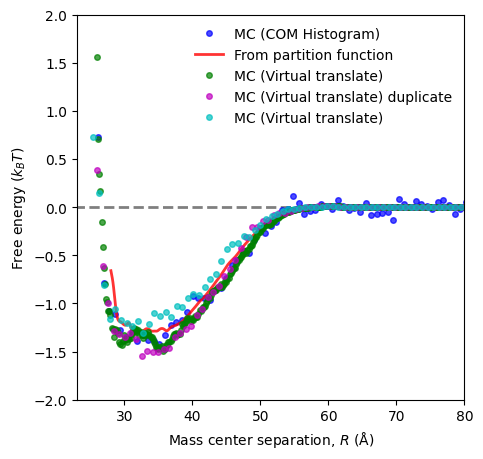

In [5]:
fig, ax = plt.subplots(nrows=1, figsize=(5, 5))
r_com, pmf_com = com_distance_to_pmf("1AMM_new/results/dat/com_distance_293.0.dat.gz", bins=100)
correction_com, pmf_com_corr = pmf_tail_correction(r_com, pmf_com)
ax.hlines(0, xmin=r_com[0]-10, xmax=r_com[-1]+10, color='k', alpha=0.5, ls='--', lw=2)
ax.plot(r_com, pmf_com_corr, 'bo', lw=3, label="MC (COM Histogram)", alpha=0.7, ms=4)
B2_com = calculate_b2(r_com[2:], pmf_com[2:], "COM")
B2_com = calculate_b2(r_com[2:], pmf_com_corr[2:], "COM")
B2_com = calculate_b2(r_com[1:], pmf_com[1:], "COM")
B2_com = calculate_b2(r_com[1:], pmf_com_corr[1:], "COM")

r_duello, pmf_duello = np.loadtxt("../duello_calculations/1AMM/epsilon_0.8368_res_0.28_dr_0.1/scans/scan_T293.dat", usecols=[0,1], unpack=True)
ax.plot(r_duello[50:-200], pmf_duello[50:-200], label="From partition function", lw=2, alpha=0.8, color='red')
B2_com = calculate_b2(r_duello[50:-200], pmf_duello[50:-200], "Duello")

r_vt_1, pmf_vt_1 = virtual_translate_to_pmf("1AMM_new/results/dat/com_distance_293.0.dat.gz", "1AMM_new/results/dat/vt.dat_293.0.gz", 500)
correction_vt_1, pmf_vt_1_corr = pmf_tail_correction(r_vt_1, pmf_vt_1)
ax.plot(r_vt_1[:-20], - pmf_vt_1_corr[:-20], 'go', lw=3, label="MC (Virtual translate)", alpha=0.7, ms=4)
B2_com = calculate_b2(r_vt_1[:-20], pmf_vt_1_corr[:-20], "VT")

r_vt_2, pmf_vt_2 = virtual_translate_to_pmf("1AMM_new_2/results/dat/com_distance_293.0.dat.gz", "1AMM_new_2/results/dat/vt.dat_293.0.gz", 100)
correction_vt_2, pmf_vt_2_corr = pmf_tail_correction(r_vt_2, pmf_vt_2)
ax.plot(r_vt_2, - pmf_vt_2_corr, 'mo', lw=3, label="MC (Virtual translate) duplicate", alpha=0.7, ms=4)
B2_com = calculate_b2(r_vt_2, pmf_vt_2_corr, "VT_2")

r_vt_3, pmf_vt_3 = virtual_translate_to_pmf("1AMM_new_3/results/dat/com_distance_293.0.dat.gz", "1AMM_new_3/results/dat/vt.dat_293.0.gz", 100)
correction_vt_3, pmf_vt_3_corr = pmf_tail_correction(r_vt_3, pmf_vt_3)
ax.plot(r_vt_3, pmf_vt_3_corr, 'co', lw=3, label="MC (Virtual translate)", alpha=0.7, ms=4)

ax.set_ylabel("Free energy ($k_BT$)")
ax.set_xlabel("Mass center separation, $R$ (Å)")
ax.legend(loc=0, frameon=False)
ax.set_xlim(23, 80)
ax.set_ylim(-2, 2)
plt.savefig("g-crystallin.png", bbox_inches="tight", dpi=300)
plt.show()